In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'savefig.dpi':300, 'axes.labelweight':'normal'})
matplotlib.rcParams['axes.linewidth'] = 0.8
from matplotlib import rc
preamble = r'''
\usepackage{physics} \usepackage{mhchem}'''
plt.rc('text.latex', preamble=preamble)
rc('text', usetex=True)

import os 
import seaborn as sns

from takarada_funkcije import *

def colorFader(c1, c2, mix=0.5):
    c1 = np.array(matplotlib.colors.to_rgb(c1))
    c2 = np.array(matplotlib.colors.to_rgb(c2))
    return matplotlib.colors.to_hex((1-mix)*c1 + mix*c2)

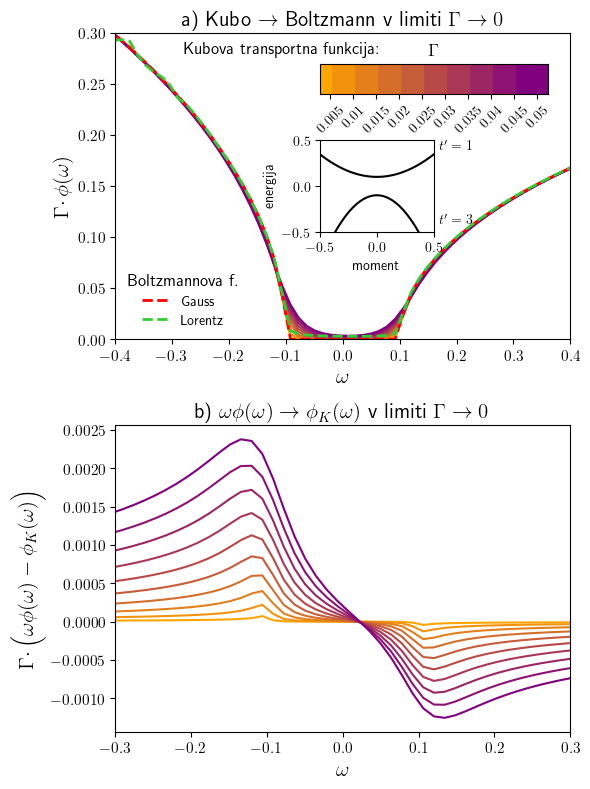

In [123]:
os.chdir('/Users/ana/Desktop/takarada/podatki')

omegas = np.linspace(-0.7,0.7,100)
Gammas = np.linspace(0.005,0.05,10)
phis = np.load('phis_Kubo.npy')

c1, c2 = 'orange', 'purple'

fig, ax = plt.subplots(nrows=2, figsize=(6, 8))
ins = ax[0].inset_axes([0.45,0.8,0.5,0.1])
for i, Gamma in enumerate(Gammas):
    c = colorFader(c1, c2, i/(len(Gammas)-1))
    ax[0].plot(omegas, np.pi * phis[i] * Gamma, color=c)
    ins.axvline(i, color=c, lw=30)

ins.set_yticks([])
ins.set_xticks(range(len(Gammas)))
ins.set_xticklabels([rf'${np.round(u,3)}$' for u in Gammas], rotation=45)
ins.set_title(r'$\Gamma$', fontsize=13)

for j in range(2):
    plt.setp(ax[j].get_yticklabels(), fontsize=11), plt.setp(ax[j].get_xticklabels(), fontsize=11)
    ax[j].set_xlabel(r'$\omega$', fontsize=15)
ax[0].set_ylabel(r'$\Gamma \cdotp \phi(\omega)$', fontsize=15)

phisB = np.load('phis_Boltzmann.npy')
ax[0].plot(omegas, phisB[0,1] / 2, color='red', ls='dashed', lw=2, label='Gauss')
ax[0].plot(omegas, phisB[1,1] / 2, color='limegreen', ls='dashed', lw=2, label='Lorentz')
ax[0].set_xlim(-0.4,0.4)
ax[0].set_ylim(-0.0,0.3)

ax[0].legend(loc='lower left', frameon=False).set_title(r'Boltzmannova f.', prop={'size':12})

ax[0].text(-0.28,0.28, 'Kubova transportna funkcija:', fontsize=12)

ins = ax[0].inset_axes([0.45,0.35,0.25,0.3])
k, e1, e2 = np.load('disperzija.npy')
ins.plot(k, e1, color='black')
ins.plot(k, e2, color='black')
ins.text(0.55, 0.4, "$t'=1$")
ins.text(0.55, -0.4, "$t'=3$")
ins.set_ylim(-0.5,0.5)
ins.set_xlim(-0.5,0.5)
ins.set_xlabel(r'moment')
ins.set_ylabel(r'energija')

phisK = np.load('phis_K.npy')

for i, Gamma in enumerate(Gammas):
    c = colorFader(c1, c2, i/(len(Gammas)-1))
    ax[1].plot(omegas, np.pi * phis[i] * Gamma * omegas - np.pi * phisK[i] * Gamma, color=c)
#ax[1].plot(omegas, np.pi * phisK[i] * Gamma, color='black', ls='dashed')
ax[1].set_ylabel(r'$\Gamma \cdotp \Bigl(\omega\phi(\omega) - \phi_K(\omega)\Bigr)$', fontsize=15)
ax[1].set_xlim([-0.3,0.3])

ax[0].set_title(r'a) Kubo $\to$ Boltzmann v limiti $\Gamma\to0$', fontsize=15)
ax[1].set_title(r'b) $\omega\phi(\omega) \to \phi_K(\omega)$ v limiti $\Gamma\to0$', fontsize=15)



plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')

plt.savefig('nonint.pdf')


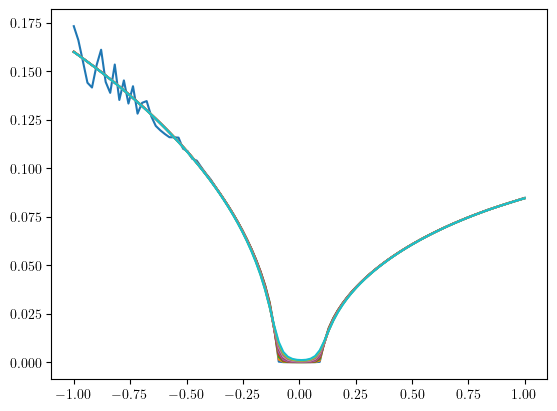

In [ ]:
omegas = np.linspace(-0.7,0.7,100)
Gammas = np.linspace(0.005,0.05,10)

phis = np.zeros((len(Gammas), len(omegas)))
for i, Gamma in enumerate(Gammas):
    phi4 = phi_Kubo(m.K, m.vecs, m.energije, j_tok(m.K, phys_parameters, m.mu), m.mu, omegas, Gamma)
    phis[i] = phi_Kubo(m.K, m.vecs, m.energije, j_tok(m.K, phys_parameters, m.mu), m.mu, omegas, Gamma)
os.chdir('/Users/ana/Desktop/takarada/podatki')
np.save('phis_Kubo.npy', phis)


Gamma = 0.03
phi1 = phi_Boltzmann(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, shape='Gaussian', faktor=0.5)
phi2 = phi_Boltzmann(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, shape='Lorentzian', faktor=0.2)
phi3 = phi_K(m.K, m.vecs, m.energije, j_tok(m.K, phys_parameters, m.mu), j_1(m.K, phys_parameters, m.mu), m.mu, omegas, Gamma)
phi4 = phi_Kubo(m.K, m.vecs, m.energije, j_tok(m.K, phys_parameters, m.mu), m.mu, omegas, Gamma)

#plt.plot(omegas, phi4 * np.pi)
#plt.plot(omegas, phi1 / (2*Gamma))

In [3]:
# example (c)
a = 1
b = 0
t = 5
t_ = 1
t12 = 0
epsilon = 5.75
Vb = 2
Vc = 2

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

scale = 1.02
beta0 = 110
betas = [100 - 5*i for i in range(20)]
Ts = 1/np.array(betas)
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]

Gamma = 0.01
eps = 1e-9
Nomega = 150

collect0 = []
collect1 = []
collect1_ = []

collect0b = []
collect1b = []

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()



/Users/ana/Desktop/takarada/takarada_funkcije.py:86: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:98: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:99: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,-i], 1/(1 + np.exp((en - mu)/T)))


found mu in the Ground state


In [4]:
omegas = np.linspace(-1,1,100)
phi1 = phi_Boltzmann(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, shape='Gaussian', faktor=0.5)
phi2 = phi_Boltzmann(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, shape='Lorentzian', faktor=0.2)
phi3 = phi_Boltzmann(m.K, m.rho, phys_parameters, m.energije, m.mu, omegas, shape='Lorentzian', faktor=0.2)

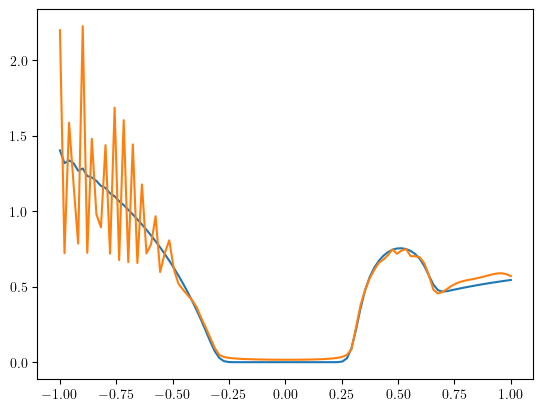

In [34]:
plt.plot(omegas, phi1)
plt.plot(omegas, phi2)


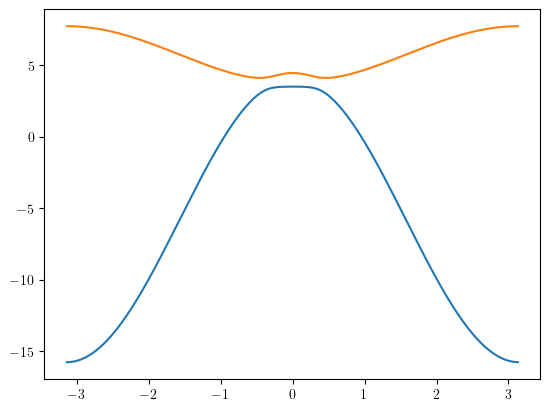

In [30]:
plt.plot(m.K, m.energije[0])
plt.plot(m.K, m.energije[1])

In [10]:
# example (c)
a = 1
b = 0
t = 3
t_ = 1
t12 = 0.
epsilon = 4.1
Vb = 0
Vc = 0

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

scale = 1.02
beta0 = 230
betas = np.hstack([np.linspace(30,220,80)[::-1], np.linspace(15,30,80)[::-1]])
Ts = 1/np.array(betas)
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]

Gamma = 0.01
eps = 1e-9
Nomega = 150

collect = np.zeros((2, 3, len(Ts)))

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()


found mu in the Ground state


In [11]:


for i, T in enumerate(Ts):
    m.reset(mu0)
    set_betas = beta0/scale**np.arange(ends[i])
    set_Ts = 1/set_betas
    m.run(set_Ts, Gamma)

    omega_max = np.sqrt(np.abs(np.arccosh(1/(4*eps*4*T)))) * 2 * T
    omegas = np.linspace(-omega_max, omega_max, Nomega)

    rez = Phit(m.K, m.vecs, m.energije, phys_parameters, m.mu, omegas, Gamma)
    
    K0 = np.sum(-fd_1(omegas, m.Ts[-1]) * rez['phi'].real) * np.pi
    K1_b = np.sum(-fd_1(omegas, m.Ts[-1]) * rez['phi'].real * omegas) * np.pi
    
    K0_boltz, K1_boltz = Kn_boltz(m.K, m.energije, m.mu, m.Ts[-1])

    collect[0,0,i] = K0
    collect[0,1,i] = K0
    collect[0,2,i] = K0_boltz / (2*Gamma)

    collect[1,1,i] = K1_b
    collect[1,2,i] = K1_boltz / (2*Gamma)

    print(f'calculated S at T={T}')


/Users/ana/Desktop/takarada/takarada_funkcije.py:86: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:98: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:99: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,-i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:351: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:, :, i], 1/(1 + np.exp((self.energije[:,i] - self.mu)/T)))


230.0 6.292868451483904e-05 1.0000000000008071 [np.float64(0.0), np.float64(0.0)]
225.49019607843138 6.292868451483895e-05 1.0000000000012799 [np.float64(0.0), np.float64(0.0)]


/Users/ana/Desktop/takarada/takarada_funkcije.py:196: RuntimeWarning: overflow encountered in cosh
  def fd_1(omega, T): return -1/(4*T)/np.cosh(omega/(2*T))**2
/Users/ana/Desktop/takarada/takarada_funkcije.py:196: RuntimeWarning: overflow encountered in scalar power
  def fd_1(omega, T): return -1/(4*T)/np.cosh(omega/(2*T))**2


calculated S at T=0.004545454545454545
230.0 6.292868451483904e-05 1.0000000000008071 [np.float64(0.0), np.float64(0.0)]
225.49019607843138 6.292868451483895e-05 1.0000000000012799 [np.float64(0.0), np.float64(0.0)]
calculated S at T=0.004595695171611402
230.0 6.292868451483904e-05 1.0000000000008071 [np.float64(0.0), np.float64(0.0)]
225.49019607843138 6.292868451483895e-05 1.0000000000012799 [np.float64(0.0), np.float64(0.0)]
221.0688196847366 6.292868451483878e-05 1.000000000002011 [np.float64(0.0), np.float64(0.0)]
calculated S at T=0.004647058823529412
230.0 6.292868451483904e-05 1.0000000000008071 [np.float64(0.0), np.float64(0.0)]
225.49019607843138 6.292868451483895e-05 1.0000000000012799 [np.float64(0.0), np.float64(0.0)]
221.0688196847366 6.292868451483878e-05 1.000000000002011 [np.float64(0.0), np.float64(0.0)]
calculated S at T=0.004699583581201666
230.0 6.292868451483904e-05 1.0000000000008071 [np.float64(0.0), np.float64(0.0)]
225.49019607843138 6.292868451483895e-05 1.00

In [308]:
a = 1
b = 0
t = 3
t_ = 1
t12 = 0.
epsilon = 4.1
Vb = 0
Vc = 0

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

mu0 = 0.
Nk = 200
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m2 = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m2.GS()

Nomega = 200
Gamma = 0.01
T = 1/100
eps = 1e-8
omega_max = np.sqrt(np.abs(np.arccosh(1/(4*eps*4*T)))) * 2 * T
omegas = np.linspace(-omega_max, omega_max, Nomega)


rez = Phit(m2.K, m2.rho, m2.vecs, m2.energije, phys_parameters, m2.mu, omegas, Gamma)
rez_boltz = Phi_boltz(m2.K, m2.rho, phys_parameters, m2.energije, m2.mu, omegas, faktor=0.5)

Gammas = [0.001, 0.005, 0.01, 0.015]
phisQ = np.zeros((2, len(Gammas), len(omegas)))
for i, g in enumerate(Gammas):
    rez = Phit(m2.K, m2.rho, m2.vecs, m2.energije, phys_parameters, m2.mu, omegas, g)
    phisQ[0,i] = rez['phiK'].real * np.pi
    phisQ[1,i] = omegas * rez['phi'].real * np.pi

found mu in the Ground state


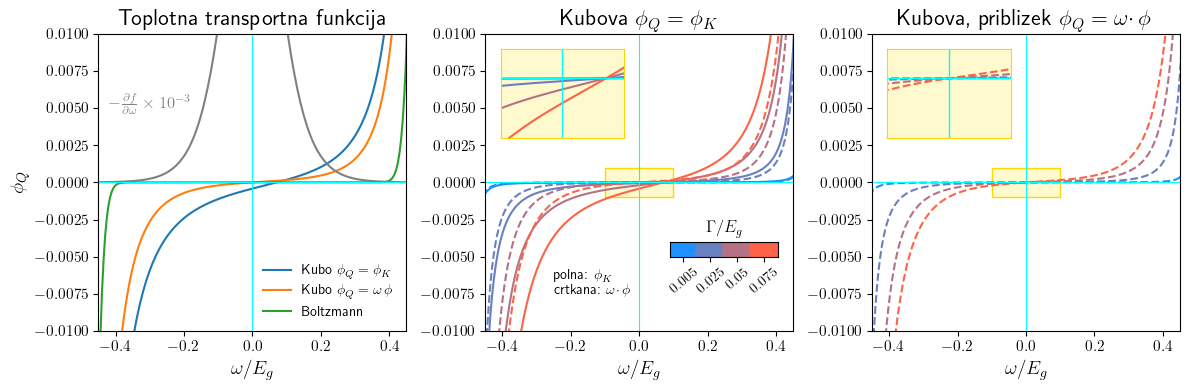

In [319]:
%matplotlib inline
fig, ax = plt.subplots(ncols=3, figsize=(12,4))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

ax[0].plot(omegas/gap, rez['phiK'].real * np.pi, label=r'Kubo $\phi_Q=\phi_K$')
ax[0].plot(omegas/gap, omegas * rez['phi'].real * np.pi, label=r'Kubo $\phi_Q=\omega\,\phi$')
ax[0].plot(omegas/gap, omegas * rez_boltz / (2 * Gamma), label='Boltzmann')
ax[0].plot(omegas/gap, -fd_1(omegas, T) * 1e-3, color='grey')
ax[0].text(-0.06/gap, 0.005, r'$-\frac{\partial f}{\partial \omega} \times 10^{-3}$', ha='center', fontsize=12, color='grey')
ax[0].legend(frameon=False, loc='lower right')

c1 = 'dodgerblue'
c2 = 'tomato'

ins = ax[1].inset_axes([0.6,0.25,0.35,0.05])

ins1 = ax[1].inset_axes([0.05,0.65,0.4,0.3])
ins2 = ax[2].inset_axes([0.05,0.65,0.4,0.3])

for i, g in enumerate(Gammas):
    ax[1].plot(omegas/gap, phisQ[0,i], color=colorFader(c1, c2, i/(len(Gammas) - 1)))
    ax[1].plot(omegas/gap, phisQ[1,i], color=colorFader(c1, c2, i/(len(Gammas) - 1)), ls='dashed')
    ax[2].plot(omegas/gap, phisQ[1,i], color=colorFader(c1, c2, i/(len(Gammas) - 1)), ls='dashed')
    ins1.plot(omegas/gap, phisQ[0,i], color=colorFader(c1, c2, i/(len(Gammas) - 1)))
    ins2.plot(omegas/gap, phisQ[1,i], color=colorFader(c1, c2, i/(len(Gammas) - 1)), ls='dashed')
    ins.axvline(i, lw=22, color=colorFader(c1, c2, i/(len(Gammas) - 1)))

for j in range(len(ax)):
    ax[j].set_ylim(-0.01,0.01)
    ax[j].set_xlim(-0.45,0.45)
    ax[j].axvline(0, color='cyan', lw=0.8)
    ax[j].axhline(0, color='cyan', lw=0.8)
    plt.setp(ax[j].get_yticklabels(), fontsize=11), plt.setp(ax[j].get_xticklabels(), fontsize=11, rotation=0)
    ax[j].set_xlabel(r'$\omega/E_g$', fontsize=14)

ins.set_xlim(-0.5,3.5)
ins.set_xticks(range(4)), ins.set_xticklabels([rf'${np.round(u/gap,3)}$' for u in Gammas], rotation=40)
ins.set_title(r'$\Gamma/E_g$')

for j in [1,2]:
    rect = matplotlib.patches.Rectangle((-0.1, -0.001), 0.2, 0.002, linewidth=1, edgecolor='gold', facecolor='lemonchiffon')
    ax[j].add_patch(rect)

for i in [ins1, ins2]:
    i.spines['bottom'].set_color('gold')
    i.spines['top'].set_color('gold') 
    i.spines['right'].set_color('gold')
    i.spines['left'].set_color('gold')
    i.set_xticks([]), i.set_yticks([])
    i.set_facecolor('lemonchiffon')
    i.set_facecolor('lemonchiffon')
    i.set_xlim(-0.1,0.1)
    i.set_ylim(-0.001,0.0005)
    i.axvline(0, color='cyan', lw=1)
    i.axhline(0, color='cyan', lw=1)

ax[0].set_ylabel(r'$\phi_Q$', fontsize=14)
ax[0].set_title(r'Toplotna transportna funkcija', fontsize=16)
ax[1].set_title(r'Kubova $\phi_Q = \phi_K$', fontsize=16)
ax[2].set_title(r'Kubova, priblizek $\phi_Q = \omega \cdotp \phi$', fontsize=16)

ax[1].text(-0.25, -0.0075, r'polna: $\phi_K$' + '\n' + r'crtkana: $\omega\cdotp\phi$')


ins.set_yticks([])
plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('transportne_fje.pdf')
plt.show()

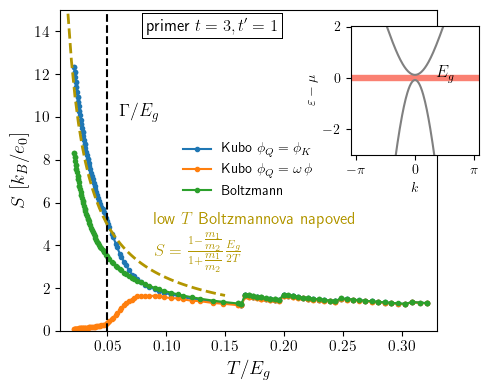

In [367]:
fig, ax = plt.subplots(figsize=(5,4))
gap = np.min(m.energije[1]) - np.max(m.energije[0])

plt.plot(np.array(m.Ts)/gap, - collect[1,0] / collect[0,0] / np.array(m.Ts), '.-', label=r'Kubo $\phi_Q=\phi_K$')
plt.plot(np.array(m.Ts)/gap, - collect[1,1] / collect[0,1] / np.array(m.Ts), '.-', label=r'Kubo $\phi_Q=\omega\,\phi$')
plt.plot(np.array(m.Ts)/gap, - collect[1,2] / collect[0,2] / np.array(m.Ts), '.-', label='Boltzmann')
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.setp(ax.get_yticklabels(), fontsize=11), plt.setp(ax.get_xticklabels(), fontsize=11)

ins = ax.inset_axes([0.77,0.55,0.34,0.4])
ins.plot(m.K, m.energije[0] - m.mu, color='grey')
ins.plot(m.K, m.energije[1] - m.mu, color='grey')
ins.set_xlabel(r'$k$'), ins.set_ylabel(r'$\varepsilon - \mu$')
ins.set_ylim(-1-m.mu,4 - m.mu)
ins.axhspan(np.max(m.energije[0]) - m.mu, np.min(m.energije[1]) - m.mu, color='salmon')
ins.text(np.pi/2, 0, r'$E_g$', ha='center', fontsize=12)
ins.set_xticks([-np.pi, 0, np.pi])
ins.set_xticklabels([r'$-\pi$', '$0$', r'$\pi$'])

plt.axvline(Gamma / gap, color='black', ls='dashed')
plt.text(0.06, 10, r'$\Gamma/E_g$', fontsize=13)
plt.xlabel(r'$T/E_g$', fontsize=14)
plt.ylabel(r'$S\,\,[k_B/e_0]$', fontsize=14)
plt.text(0.08, 14, r"$\boxed{\text{primer} \,\, t=3,t'=1}$", fontsize=12)

xs = np.linspace(0.001, 0.03)
plt.plot(xs/gap, (1-1/3)/(1+1/3) * gap / (2*xs), color=colorFader('gold', 'black', 0.3), ls='dashed', lw=2)
plt.legend(frameon=False, loc='center')
plt.text(0.09,3.5,r"low $T$ Boltzmannova napoved" + '\n' + r"$S = \frac{1-\tfrac{m_1}{m_2}}{1+\tfrac{m_1}{m_2}} \frac{E_g}{2T}$", color=colorFader('gold', 'black', 0.3), fontsize=12)
plt.ylim(0,15)
plt.xlim(0.01,0.33)
plt.tight_layout()
os.chdir('/Users/ana/Desktop/takarada/slike')
plt.savefig('seebeck.pdf')
plt.show()

In [4]:
# example (c)
a = 1
b = 0
t = 5
t_ = 1
t12 = 0
epsilon = 5.75
Vb = 2
Vc = 2

phys_parameters = {'b': b,
                   't': t,
                    't_': t_,
                    't12': t12,
                    'epsilon': epsilon,
                    'Vb': Vb,
                    'Vc': Vc}

scale = 1.02
beta0 = 110
betas = [100 - 5*i for i in range(20)]
Ts = 1/np.array(betas)
ends = [int(np.emath.logn(scale, beta0/beta)) for beta in betas]

Gamma = 0.01
eps = 1e-9
Nomega = 150

collect0 = []
collect1 = []
collect1_ = []

collect0b = []
collect1b = []

mu0 = 0.
include_hartree = False
mu0 = find_GS_mu(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree, beta0=50, beta1=40)
m = model(Nk, mu0, phys_parameters, parameters1, parameters2, include_hartree)
m.GS()



/Users/ana/Desktop/takarada/takarada_funkcije.py:86: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:98: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,i], 1/(1 + np.exp((en - mu)/T)))
/Users/ana/Desktop/takarada/takarada_funkcije.py:99: RuntimeWarning: overflow encountered in exp
  np.fill_diagonal(fs[:,:,-i], 1/(1 + np.exp((en - mu)/T)))


found mu in the Ground state
